In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
# Directory containing the CSV files
OUTPUT_DIR       = Path("/global/cfs/cdirs/e3smdata/simulations/v3.XLE")
OUTPUT_SUBDIR    = Path("post/e3sm_diags")
OUTPUT_FILENAME  = "ANN_metrics_table.csv"

ENSEMBLE_MEMBERS = ['0051', '0091', '0101', '0111', '0121',
                    '0131', '0141', '0151', '0161', '0171', 
                    '0181', '0191', '0201', '0211', '0221', 
                    '0231', '0241', '0251', '0261', '0271', 
                    '0281', '0291', '0301', '0311', '0321']

# Metrics to extract (from Variables column)
metrics = [
    "RESTOM global ceres_ebaf_toa_v4.1",
    "SWCF global ceres_ebaf_toa_v4.1",
    "LWCF global ceres_ebaf_toa_v4.1",
    "PRECT global GPCP_v3.2",
    "PSL global ERA5",
    "TREFHT land ERA5",
    "U-200mb global ERA5",
    "U-850mb global ERA5",
    "Z3-500mb global ERA5",
]

# Short labels for plotting
metric_labels = [
    "Net TOA (W/m2)",
    "SW CRE (W/m2)",
    "LW CRE (W/m2)", 
    "PREC (mm/day)",
    "SLP (hPa)",
    "TAS land (K)",
    "U-200 (m/s)",
    "U-850 (m/s)",
    "Z3-500 (hm)",
]

# Model configuration info
configs = {
    'Default': {
        'pattern': 'v3.LR.historical_',
        'color': 'tab:green',
        'files': []
    },
    'lowECS': {
        'pattern': 'v3.LR.lowECS.historical_',
        'color': 'tab:blue',
        'files': []
    },
    'highECS': {
        'pattern': 'v3.LR.highECS.historical_',
        'color': 'tab:red',
        'files': []
    }
}

# Get CSV files for each configuration and ensemble member
for config_name, config_info in configs.items():
    for member in ENSEMBLE_MEMBERS:
        csv_path = OUTPUT_DIR / f"{config_info['pattern']}{member}" / OUTPUT_SUBDIR / OUTPUT_FILENAME
        if csv_path.exists():
            config_info['files'].append(csv_path)
        else:
            print(f"Warning: File not found: {csv_path}")

# Print counts
print("File counts:")
for config_name, config_info in configs.items():
    print(f"  {config_name}: {len(config_info['files'])} files")

# Determine minimum ensemble size
min_ensemble_size = min(len(config_info['files']) for config_info in configs.values())
print(f"\nUsing {min_ensemble_size} ensembles from each configuration\n")

# Limit each configuration to the minimum ensemble size
for config_name in configs:
    configs[config_name]['files'] = configs[config_name]['files'][:min_ensemble_size]

# Extract RMSE data for each metric and configuration
rmse_data = {metric: {config: [] for config in configs.keys()} for metric in metrics}

for config_name, config_info in configs.items():
    for csv_file in config_info['files']:
        try:
            df = pd.read_csv(csv_file)
            
            for metric in metrics:
                # Find the row matching this metric
                row = df[df['Variables'] == metric]
                
                if not row.empty:
                    rmse_value = row['RMSE'].values[0]
                    # Check for valid data (not NaN and not 999.999 which seems to be missing data indicator)
                    if pd.notna(rmse_value) and rmse_value != 999.999:
                        rmse_data[metric][config_name].append(rmse_value)
                    else:
                        print(f"Warning: Invalid RMSE for {metric} in {csv_file.name}")
                else:
                    print(f"Warning: Metric '{metric}' not found in {csv_file.name}")
                    
        except Exception as e:
            print(f"Error reading {csv_file.name}: {e}")


File counts:
  Default: 25 files
  lowECS: 25 files
  highECS: 25 files

Using 25 ensembles from each configuration



In [3]:
# Read in the CMIP6 RMSE data from a CSV file
cmip6_csv_path = Path("/global/cfs/cdirs/e3smdata/simulations/v3.XLE/cmip6_historical_seasonal_rmse_202203.csv")
cmip6_metrics  = ['Model', 'Net TOA', 'SW CRE', 'LW CRE', 'prec', 'tas land', 'SLP', 'u-200', 'u-850', 'Zg-500']
if cmip6_csv_path.exists():
    cmip6_df_orig = pd.read_csv(cmip6_csv_path)
    cmip6_df      = cmip6_df_orig[cmip6_metrics]
    cmip6_df      = cmip6_df[cmip6_metrics]
    cmip6_df      = cmip6_df.drop([0, 1])
    cmip6_df      = cmip6_df[cmip6_df['Model'] != 'E3SM-2-0']
    cmip6_df      = cmip6_df[cmip6_df['Model'] != 'E3SM-3-0']
    cmip6_df      = cmip6_df[cmip6_df['Model'] != 'E3SM-2-0 (composite base)']
    cmip6_df      = cmip6_df[cmip6_df['Model'] != 'E3SM-2-0 (composite best)']


In [4]:
figure_dir = '/pscratch/sd/b/beharrop/E3SMv3/XLE/figures/'


RESTOM global ceres_ebaf_toa_v4.1:
  lowECS: mean=9.725, std=0.045, n=25
  Default: mean=9.158, std=0.075, n=25
  highECS: mean=8.786, std=0.061, n=25

SWCF global ceres_ebaf_toa_v4.1:
  lowECS: mean=13.906, std=0.050, n=25
  Default: mean=12.032, std=0.063, n=25
  highECS: mean=12.552, std=0.077, n=25

LWCF global ceres_ebaf_toa_v4.1:
  lowECS: mean=5.801, std=0.064, n=25
  Default: mean=4.938, std=0.082, n=25
  highECS: mean=4.534, std=0.089, n=25

PRECT global GPCP_v3.2:
  lowECS: mean=1.053, std=0.010, n=25
  Default: mean=1.050, std=0.018, n=25
  highECS: mean=1.023, std=0.012, n=25

PSL global ERA5:
  lowECS: mean=2.624, std=0.056, n=25
  Default: mean=2.621, std=0.076, n=25
  highECS: mean=2.327, std=0.066, n=25

TREFHT land ERA5:
  lowECS: mean=2.018, std=0.012, n=25
  Default: mean=1.926, std=0.009, n=25
  highECS: mean=2.065, std=0.031, n=25

U-200mb global ERA5:
  lowECS: mean=2.964, std=0.061, n=25
  Default: mean=3.284, std=0.091, n=25
  highECS: mean=3.345, std=0.093, n=

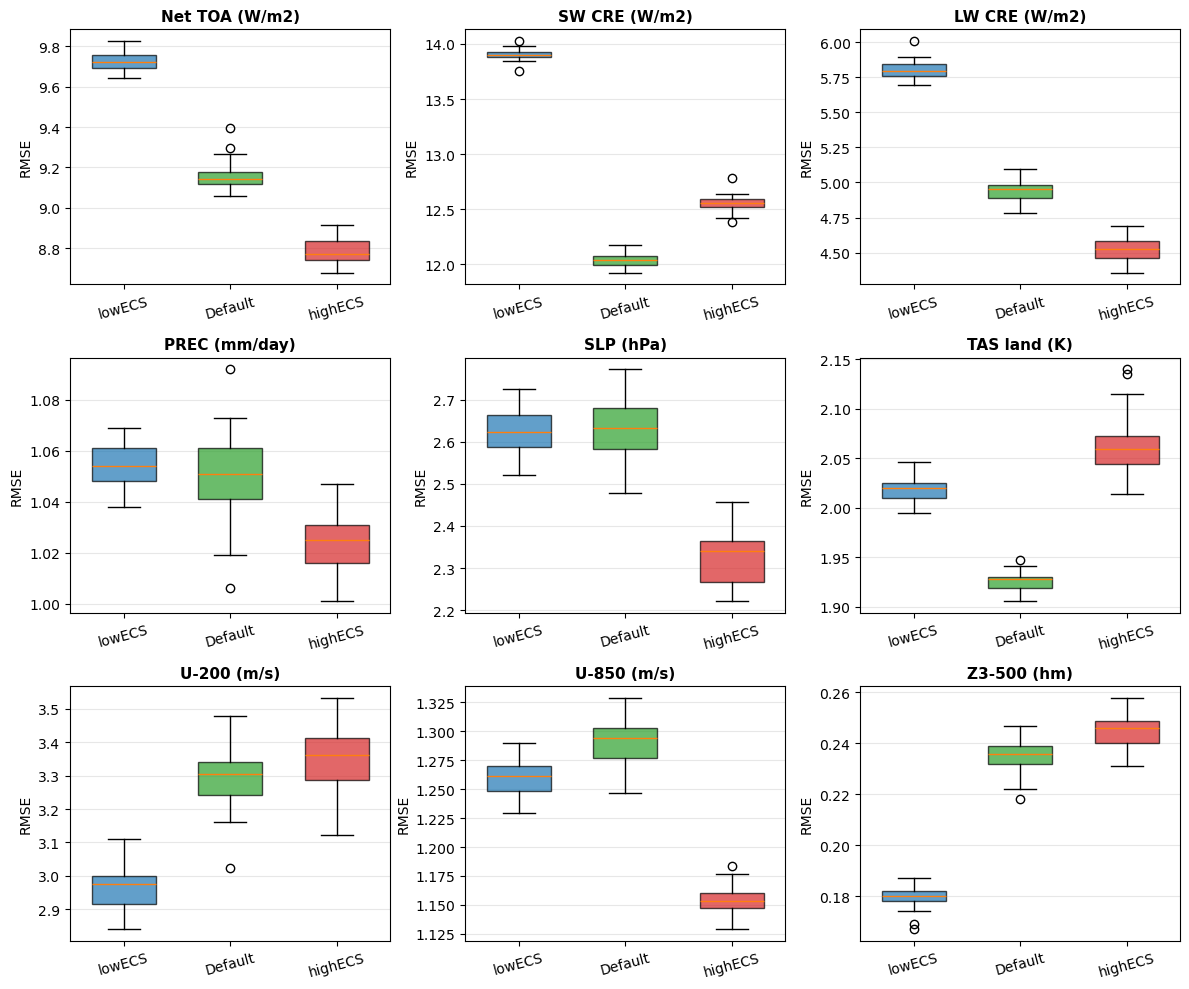

In [5]:
# Create the figure with 8 subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

config_list = ['lowECS', 'Default', 'highECS']

# Create box plots
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_to_plot = [rmse_data[metric][config] for config in config_list]
    colors = [configs[config]['color'] for config in config_list]
    
    # Create box plot
    bp = ax.boxplot(data_to_plot, 
                    tick_labels=config_list,
                    patch_artist=True,
                    widths=0.6)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Styling
    ax.set_ylabel('RMSE', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)
    
    # Print statistics
    print(f"\n{metric}:")
    for config in config_list:
        values = rmse_data[metric][config]
        if values:
            print(f"  {config}: mean={np.mean(values):.3f}, std={np.std(values):.3f}, n={len(values)}")

plt.tight_layout()
plt.savefig(figure_dir + 'rmse_comparison_simple.png', dpi=300, bbox_inches='tight')
print("\nFigure saved as 'rmse_comparison_simple.png'")
plt.show()


RESTOM global ceres_ebaf_toa_v4.1:
  lowECS: mean=9.725, std=0.045, n=25
  Default: mean=9.158, std=0.075, n=25
  highECS: mean=8.786, std=0.061, n=25
  CMIP6: mean=10.508, std=2.006, n=37

SWCF global ceres_ebaf_toa_v4.1:
  lowECS: mean=13.906, std=0.050, n=25
  Default: mean=12.032, std=0.063, n=25
  highECS: mean=12.552, std=0.077, n=25
  CMIP6: mean=12.321, std=2.568, n=49

LWCF global ceres_ebaf_toa_v4.1:
  lowECS: mean=5.801, std=0.064, n=25
  Default: mean=4.938, std=0.082, n=25
  highECS: mean=4.534, std=0.089, n=25
  CMIP6: mean=6.620, std=1.423, n=50

PRECT global GPCP_v3.2:
  lowECS: mean=1.053, std=0.010, n=25
  Default: mean=1.050, std=0.018, n=25
  highECS: mean=1.023, std=0.012, n=25
  CMIP6: mean=1.256, std=0.204, n=51

PSL global ERA5:
  lowECS: mean=2.624, std=0.056, n=25
  Default: mean=2.621, std=0.076, n=25
  highECS: mean=2.327, std=0.066, n=25
  CMIP6: mean=2.208, std=0.746, n=51

TREFHT land ERA5:
  lowECS: mean=2.018, std=0.012, n=25
  Default: mean=1.926, std

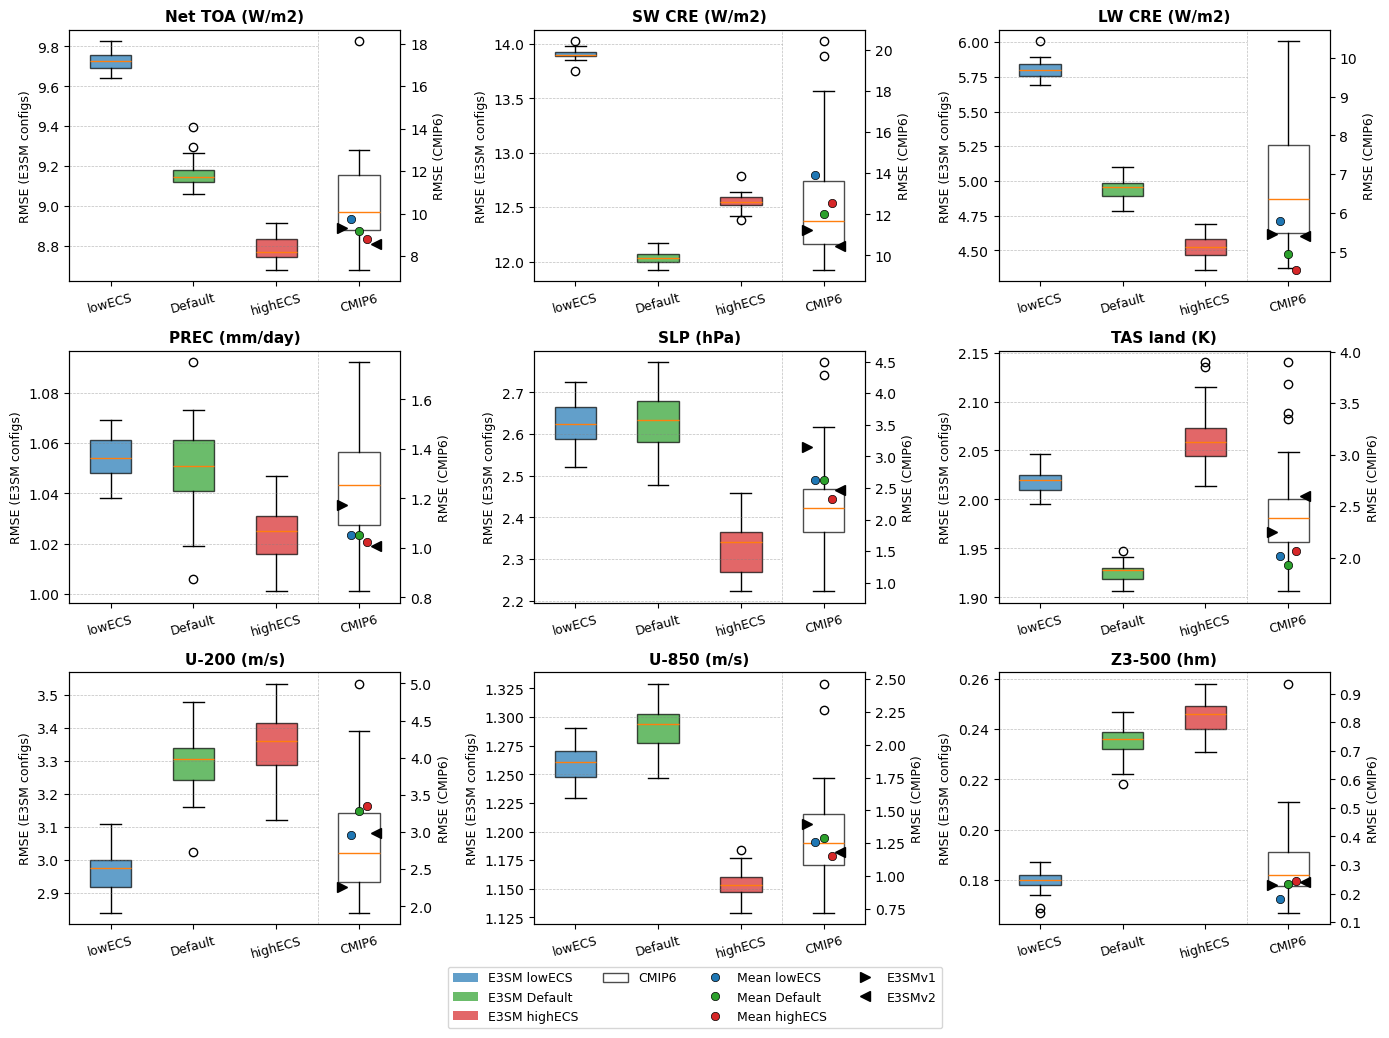

In [7]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Mapping from E3SM metric names to CMIP6 CSV column names
cmip6_column_map = {
    "RESTOM global ceres_ebaf_toa_v4.1": "Net TOA",
    "SWCF global ceres_ebaf_toa_v4.1":   "SW CRE",
    "LWCF global ceres_ebaf_toa_v4.1":   "LW CRE",
    "PRECT global GPCP_v3.2":            "prec",
    "PSL global ERA5":                   "SLP",
    "TREFHT land ERA5":                  "tas land",
    "U-200mb global ERA5":               "u-200",
    "U-850mb global ERA5":               "u-850",
    "Z3-500mb global ERA5":              "Zg-500",
}

# Pre-extract E3SM-1-0 and E3SM-2-0 from the unfiltered CMIP6 data
e3sm1_row = cmip6_df_orig[cmip6_df_orig['Model'] == 'E3SM-1-0'][cmip6_metrics]
e3sm2_row = cmip6_df_orig[cmip6_df_orig['Model'] == 'E3SM-2-0'][cmip6_metrics]

# Create the figure with 9 subplots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

config_list  = ['lowECS', 'Default', 'highECS']
offset_shift = 0.20
dot_offsets  = [-0.5 * offset_shift, 0.0, 0.5 * offset_shift]   # horizontal jitter for mean dots on CMIP6 box

# Build shared legend handles
legend_handles = []
for config in config_list:
    legend_handles.append(
        mpatches.Patch(facecolor=configs[config]['color'], alpha=0.7, label=config)
    )
legend_handles.append(
    mpatches.Patch(facecolor='white', edgecolor='black', alpha=0.7, label='CMIP6')
)
for config, offset in zip(config_list, dot_offsets):
    legend_handles.append(
        mlines.Line2D([], [], color=configs[config]['color'], marker='o',
                      linestyle='None', markersize=6,
                      markeredgecolor='black', markeredgewidth=0.5,
                      label=f'Mean {config}')
    )
legend_handles.append(
    mlines.Line2D([], [], color='black', marker='>', linestyle='None',
                  markersize=7, label='E3SMv1')
)
legend_handles.append(
    mlines.Line2D([], [], color='black', marker='<', linestyle='None',
                  markersize=7, label='E3SMv2')
)

# Create box plots
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax_left  = axes[idx]
    ax_right = ax_left.twinx()

    # --- Left axis: E3SM config box plots (positions 1–3) ---
    data_left   = [rmse_data[metric][config] for config in config_list]
    colors_left = [configs[config]['color'] for config in config_list]

    bp_left = ax_left.boxplot(data_left,
                               positions=[1, 2, 3],
                               patch_artist=True,
                               widths=0.5)
    for patch, color in zip(bp_left['boxes'], colors_left):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # --- Right axis: CMIP6 box plot (position 4) ---
    cmip6_col    = cmip6_column_map[metric]
    cmip6_values = pd.to_numeric(cmip6_df[cmip6_col], errors='coerce').dropna().tolist()

    bp_right = ax_right.boxplot([cmip6_values],
                                 positions=[4],
                                 patch_artist=True,
                                 widths=0.5)
    bp_right['boxes'][0].set_facecolor('white')
    bp_right['boxes'][0].set_alpha(0.7)

    # --- Colored mean dots on CMIP6 box (right axis) ---
    for config, offset in zip(config_list, dot_offsets):
        values = rmse_data[metric][config]
        if values:
            ax_right.plot(4 + offset, np.mean(values), 'o',
                          color=configs[config]['color'],
                          markersize=6, zorder=5,
                          markeredgecolor='black', markeredgewidth=0.5)

    # --- E3SM-1-0 right-facing triangle ('>') on right axis ---
    if not e3sm1_row.empty:
        val = pd.to_numeric(e3sm1_row[cmip6_col].values[0], errors='coerce')
        if not np.isnan(val):
            ax_right.plot(4 - offset_shift, val, '>', color='black', markersize=7, zorder=5)

    # --- E3SM-2-0 left-facing triangle ('<') on right axis ---
    if not e3sm2_row.empty:
        val = pd.to_numeric(e3sm2_row[cmip6_col].values[0], errors='coerce')
        if not np.isnan(val):
            ax_right.plot(4 + offset_shift, val, '<', color='black', markersize=7, zorder=5)

    # --- Axis formatting ---
    ax_left.set_xlim(0.5, 4.5)
    ax_left.set_xticks([1, 2, 3, 4])
    ax_left.set_xticklabels(config_list + ['CMIP6'], rotation=15, fontsize=9)
    ax_left.set_ylabel('RMSE (E3SM configs)', fontsize=9)
    ax_right.set_ylabel('RMSE (CMIP6)', fontsize=9)
    ax_left.set_title(label, fontsize=11, fontweight='bold')
    # ax_left.grid(True, alpha=0.3, axis='y')
    left_y_limits = ax_left.get_ylim()
    ax_left.plot([3.5, 3.5], left_y_limits, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax_left.set_ylim(left_y_limits)
    left_y_ticks = ax_left.get_yticks()
    for tick in left_y_ticks:
        ax_left.plot([0.5, 3.5], [tick, tick], color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Print statistics
    print(f"\n{metric}:")
    for config in config_list:
        values = rmse_data[metric][config]
        if values:
            print(f"  {config}: mean={np.mean(values):.3f}, std={np.std(values):.3f}, n={len(values)}")
    print(f"  CMIP6: mean={np.mean(cmip6_values):.3f}, std={np.std(cmip6_values):.3f}, n={len(cmip6_values)}")

#### LEGEND ####
from matplotlib.lines import Line2D

# An invisible legend entry used as padding
empty = Line2D([], [], linestyle='none', color='none')

handles = [
    legend_handles[0], legend_handles[1], legend_handles[2],       # column 1
    legend_handles[3], empty, empty, # column 2
    legend_handles[4], legend_handles[5], legend_handles[6],       # column 3
    legend_handles[7], legend_handles[8], empty     # column 4
]

labels = [
    'E3SM lowECS', 'E3SM Default', 'E3SM highECS',
    'CMIP6', '', '',
    'Mean lowECS', 'Mean Default', 'Mean highECS',
    'E3SMv1', 'E3SMv2', ''
]

fig.legend(
    handles=handles,
    labels=labels,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.04),
    fontsize=9,
    frameon=True
)

# fig.legend(handles=legend_handles, loc='lower center', ncol=4,
#            bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.savefig(figure_dir + 'rmse_comparison.png', dpi=300, bbox_inches='tight')
print("\nFigure saved as 'rmse_comparison.png'")
plt.show()